In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
from sklearn.compose import ColumnTransformer

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [12]:
from sklearn.pipeline import Pipeline

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


In [18]:
df = pd.read_excel("customer_churn_dataset.xlsx")

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1000, 8)


In [19]:
df

,CustomerID,Age,Tenure,MonthlyCharges,ContractType,PaymentMethod,TotalCharges,Churn
0,1001,56,14,67.67,One year,Bank transfer,911.91,0
1,1002,69,63,59.44,Month-to-month,Bank transfer,3621.63,0
2,1003,46,27,74.94,Month-to-month,Electronic check,2089.62,0
3,1004,32,38,94.69,Month-to-month,Mailed check,3628.75,1
4,1005,60,56,91.55,Month-to-month,Mailed check,5043.51,1
...,...,...,...,...,...,...,...,...
995,1996,60,11,100.66,Month-to-month,Mailed check,1116.55,1
996,1997,64,4,67.65,Month-to-month,Bank transfer,262.67,1
997,1998,62,47,119.61,One year,Credit card,5819.22,0
998,1999,35,36,25.95,One year,Mailed check,895.36,0


In [20]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   CustomerID  Age  Tenure  MonthlyCharges    ContractType     PaymentMethod  \
0        1001   56      14           67.67        One year     Bank transfer   
1        1002   69      63           59.44  Month-to-month     Bank transfer   
2        1003   46      27           74.94  Month-to-month  Electronic check   
3        1004   32      38           94.69  Month-to-month      Mailed check   
4        1005   60      56           91.55  Month-to-month      Mailed check   

   TotalCharges  Churn  
0        911.91      0  
1       3621.63      0  
2       2089.62      0  
3       3628.75      1  
4       5043.51      1  


In [21]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      1000 non-null   int64  
 1   Age             1000 non-null   int64  
 2   Tenure          1000 non-null   int64  
 3   MonthlyCharges  1000 non-null   float64
 4   ContractType    1000 non-null   str    
 5   PaymentMethod   1000 non-null   str    
 6   TotalCharges    1000 non-null   float64
 7   Churn           1000 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 62.6 KB
None


In [22]:
print("\nColumn Names:")
print(df.columns)



Column Names:
Index(['CustomerID', 'Age', 'Tenure', 'MonthlyCharges', 'ContractType',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='str')


In [23]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID        0
Age               0
Tenure            0
MonthlyCharges    0
ContractType      0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64


In [24]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())



Duplicate Rows:
0


In [25]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
        CustomerID         Age       Tenure  MonthlyCharges  TotalCharges  \
count  1000.000000  1000.00000  1000.000000     1000.000000   1000.000000   
mean   1500.500000    43.81900    35.083000       69.281480   2473.173760   
std     288.819436    14.99103    20.778302       28.738456   1944.427788   
min    1001.000000    18.00000     0.000000       20.020000      0.000000   
25%    1250.750000    31.00000    17.000000       43.480000    911.117500   
50%    1500.500000    44.00000    35.000000       69.165000   1979.510000   
75%    1750.250000    56.00000    53.000000       94.402500   3623.410000   
max    2000.000000    69.00000    71.000000      119.970000   8347.590000   

             Churn  
count  1000.000000  
mean      0.344000  
std       0.475279  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       1.000000  
max       1.000000  


In [26]:
print("\nChurn Distribution:")
print(df["Churn"].value_counts())


Churn Distribution:
Churn
0    656
1    344
Name: count, dtype: int64


In [27]:
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)



Churn Percentage:
Churn
0    65.6
1    34.4
Name: proportion, dtype: float64


###  CHURN VISUALIZATION

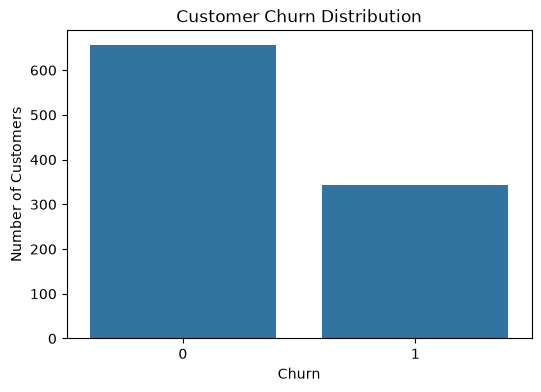

In [28]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## CONTRACT TYPE ANALYSIS

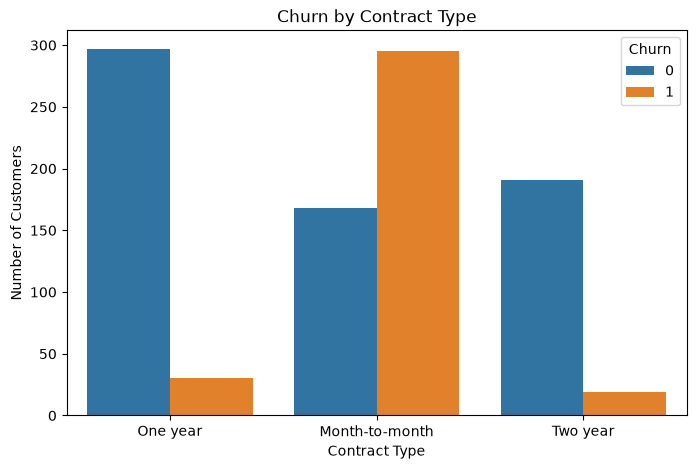

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="ContractType",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()


##  PAYMENT METHOD ANALYSIS

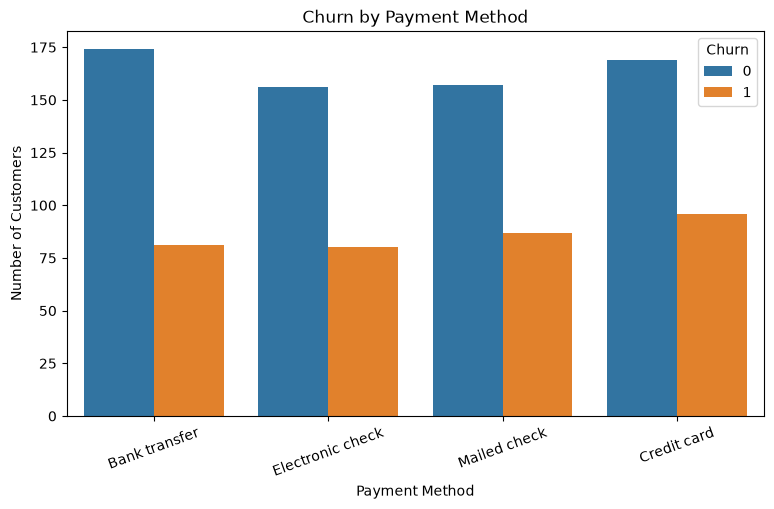

In [30]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

## MONTHLY CHARGES ANALYSIS

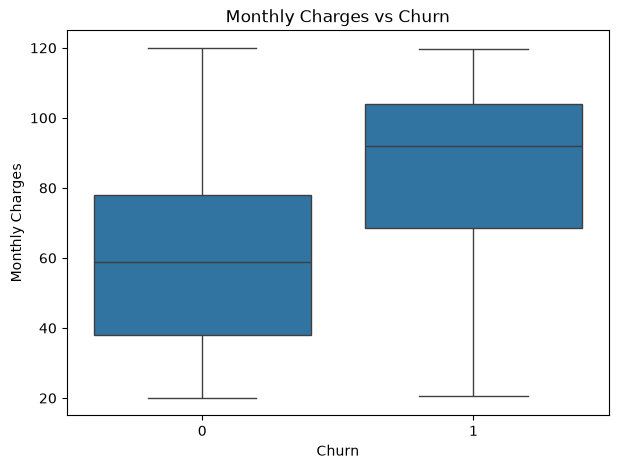

In [31]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### TENURE ANALYSIS

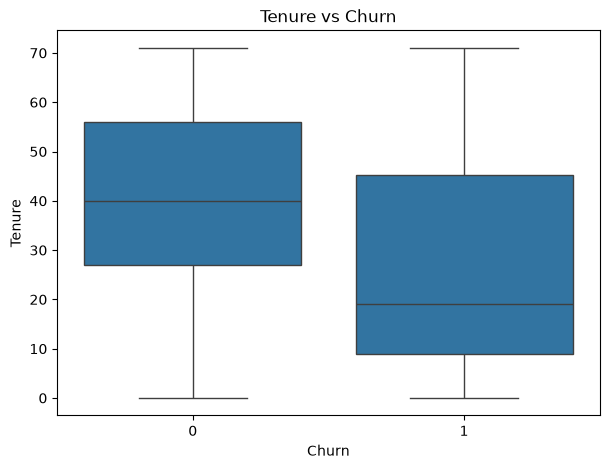

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

## CORRELATION ANALYSIS

In [36]:
numeric_columns = [
    "Age",
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
                     Age    Tenure  MonthlyCharges  TotalCharges     Churn
Age             1.000000 -0.041214        0.006878     -0.027656 -0.020896
Tenure         -0.041214  1.000000        0.075149      0.791883 -0.309515
MonthlyCharges  0.006878  0.075149        1.000000      0.586483  0.398922
TotalCharges   -0.027656  0.791883        0.586483      1.000000 -0.011509
Churn          -0.020896 -0.309515        0.398922     -0.011509  1.000000


## CORRELATION HEATMAP

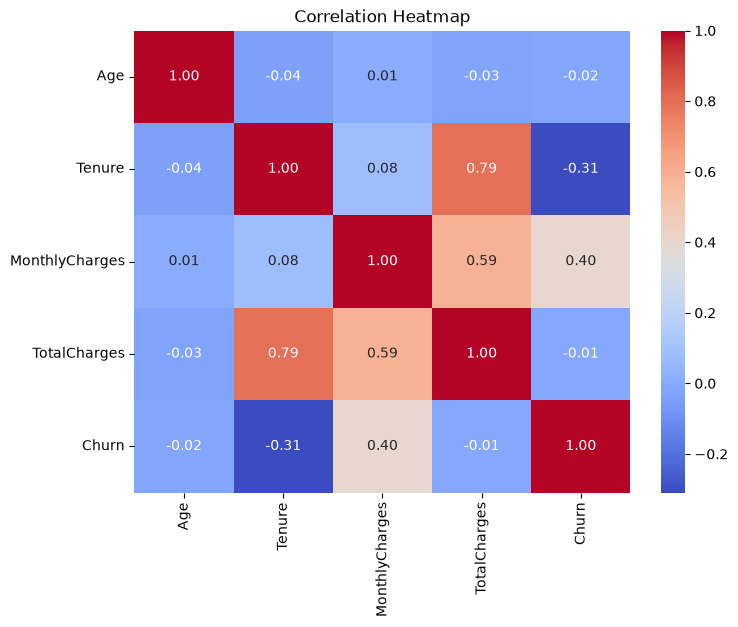

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# MACHINE LEARNING

### REMOVE CUSTOMER ID

In [40]:
X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"]

print("X (Features):")
print(X.head())

print("\ny (Target):")
print(y.head())

X (Features):
   Age  Tenure  MonthlyCharges    ContractType     PaymentMethod  TotalCharges
0   56      14           67.67        One year     Bank transfer        911.91
1   69      63           59.44  Month-to-month     Bank transfer       3621.63
2   46      27           74.94  Month-to-month  Electronic check       2089.62
3   32      38           94.69  Month-to-month      Mailed check       3628.75
4   60      56           91.55  Month-to-month      Mailed check       5043.51

y (Target):
0    0
1    0
2    0
3    1
4    1
Name: Churn, dtype: int64


###  DEFINE COLUMNS

In [41]:
numeric_columns = [
    "Age",
    "Tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']


### Identify categorical columns

In [44]:
categorical_columns = [
    "ContractType",
    "PaymentMethod"
]

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['ContractType', 'PaymentMethod']


# Preprocessing

### Create preprocessing pipeline

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


# Train/Test Split

### Split data

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split successfully!")

print("\nX_train shape:")
print(X_train.shape)

print("\nX_test shape:")
print(X_test.shape)

print("\ny_train shape:")
print(y_train.shape)

print("\ny_test shape:")
print(y_test.shape)

Data split successfully!

X_train shape:
(800, 6)

X_test shape:
(200, 6)

y_train shape:
(800,)

y_test shape:
(200,)


# Logistic Regression

### Create Logistic Regression model

In [48]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

print("Logistic Regression model created!")

Logistic Regression model created!


### Train model

In [50]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Make predictions

In [51]:
logistic_prediction = (
    logistic_model.predict(X_test)
)

print("First 20 predictions:")
print(logistic_prediction[:20])

First 20 predictions:
[0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1]


### Prediction probability

In [52]:
logistic_probability = (
    logistic_model.predict_proba(X_test)[:, 1]
)

print("First 10 prediction probabilities:")
print(logistic_probability[:10])

First 10 prediction probabilities:
[3.40974330e-02 7.03457932e-02 1.25960434e-04 3.20464414e-01
 6.36376911e-01 3.25985603e-02 6.80537105e-01 6.20578509e-03
 2.08678597e-01 5.13342265e-02]


### Accuracy

In [53]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

print("Logistic Regression Accuracy:")
print(logistic_accuracy)

print("\nAccuracy Percentage:")
print(logistic_accuracy * 100, "%")

Logistic Regression Accuracy:
0.9

Accuracy Percentage:
90.0 %


### ROC-AUC

In [54]:
logistic_auc = roc_auc_score(
    y_test,
    logistic_probability
)

print("Logistic Regression ROC-AUC:")
print(logistic_auc)

Logistic Regression ROC-AUC:
0.9639340635025998


### Classification Report

In [55]:
print("Logistic Regression Classification Report:")

print(
    classification_report(
        y_test,
        logistic_prediction
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       131
           1       0.86      0.86      0.86        69

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.90      0.90      0.90       200



### Confusion Matrix

In [56]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_prediction
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

Logistic Regression Confusion Matrix:
[[121  10]
 [ 10  59]]


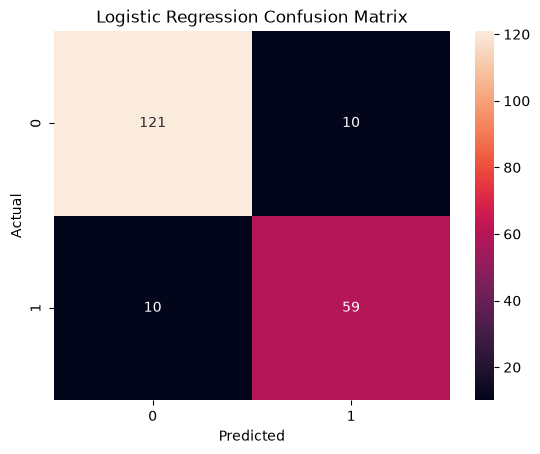

Confusion Matrix displayed.


In [57]:
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("Confusion Matrix displayed.")

# Random Forest

In [59]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("Random Forest model created!")

Random Forest model created!


### Train Random Forest

In [61]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Make predictions

In [62]:
rf_prediction = (
    random_forest_model.predict(X_test)
)

print("First 20 Random Forest predictions:")
print(rf_prediction[:20])

First 20 Random Forest predictions:
[0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1]


### Prediction probability

In [63]:
rf_probability = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)

print("First 10 Random Forest probabilities:")
print(rf_probability[:10])

First 10 Random Forest probabilities:
[0.05333333 0.03666667 0.         0.08333333 0.26       0.01
 0.95333333 0.03333333 0.01333333 0.14      ]


### Accuracy

In [64]:
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:")
print(rf_accuracy)

print("\nAccuracy Percentage:")
print(rf_accuracy * 100, "%")

Random Forest Accuracy:
0.965

Accuracy Percentage:
96.5 %


### ROC-AUC

In [66]:
rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest ROC-AUC:")
print(rf_auc)

Random Forest ROC-AUC:
0.9953534683040159


### Classification Report

In [67]:
print("Random Forest Classification Report:")

print(
    classification_report(
        y_test,
        rf_prediction
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       131
           1       0.93      0.97      0.95        69

    accuracy                           0.96       200
   macro avg       0.96      0.97      0.96       200
weighted avg       0.97      0.96      0.97       200



### Confusion Matrix

In [68]:
rf_cm = confusion_matrix(
    y_test,
    rf_prediction
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[126   5]
 [  2  67]]


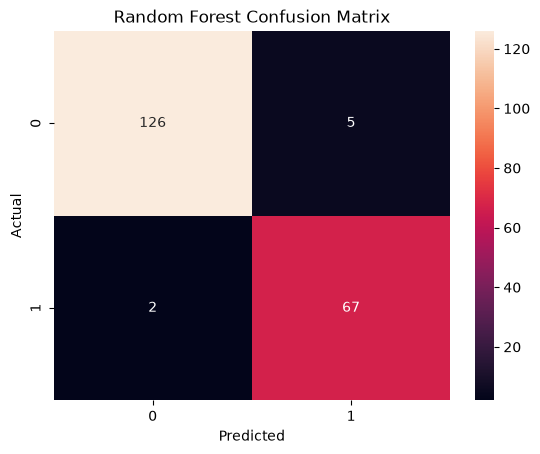

Random Forest Confusion Matrix displayed.


In [69]:
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("Random Forest Confusion Matrix displayed.")

# Feature Importance

### Get trained Random Forest

In [70]:
rf_model = (
    random_forest_model
    .named_steps["model"]
)

print("Random Forest model extracted.")

Random Forest model extracted.


### Get feature names

In [71]:
preprocessor_fitted = (
    random_forest_model
    .named_steps["preprocessing"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print("Feature Names:")
print(feature_names)

Feature Names:
['numeric__Age' 'numeric__Tenure' 'numeric__MonthlyCharges'
 'numeric__TotalCharges' 'categorical__ContractType_Month-to-month'
 'categorical__ContractType_One year' 'categorical__ContractType_Two year'
 'categorical__PaymentMethod_Bank transfer'
 'categorical__PaymentMethod_Credit card'
 'categorical__PaymentMethod_Electronic check'
 'categorical__PaymentMethod_Mailed check']


### Get importance

In [72]:
importance = rf_model.feature_importances_

print("Feature Importance:")
print(importance)

Feature Importance:
[0.02501837 0.20341827 0.25270758 0.12403843 0.24795297 0.0802814
 0.05453792 0.0031366  0.00277484 0.00277496 0.00335866]


### Create DataFrame

In [73]:
feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

print("Feature Importance DataFrame:")
print(feature_importance)

Feature Importance DataFrame:
                                        Feature  Importance
0                                  numeric__Age    0.025018
1                               numeric__Tenure    0.203418
2                       numeric__MonthlyCharges    0.252708
3                         numeric__TotalCharges    0.124038
4      categorical__ContractType_Month-to-month    0.247953
5            categorical__ContractType_One year    0.080281
6            categorical__ContractType_Two year    0.054538
7      categorical__PaymentMethod_Bank transfer    0.003137
8        categorical__PaymentMethod_Credit card    0.002775
9   categorical__PaymentMethod_Electronic check    0.002775
10      categorical__PaymentMethod_Mailed check    0.003359


### Sort importance

In [75]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("Sorted Feature Importance:")
print(feature_importance)

Sorted Feature Importance:
                                        Feature  Importance
2                       numeric__MonthlyCharges    0.252708
4      categorical__ContractType_Month-to-month    0.247953
1                               numeric__Tenure    0.203418
3                         numeric__TotalCharges    0.124038
5            categorical__ContractType_One year    0.080281
6            categorical__ContractType_Two year    0.054538
0                                  numeric__Age    0.025018
10      categorical__PaymentMethod_Mailed check    0.003359
7      categorical__PaymentMethod_Bank transfer    0.003137
9   categorical__PaymentMethod_Electronic check    0.002775
8        categorical__PaymentMethod_Credit card    0.002775


### Plot feature importance

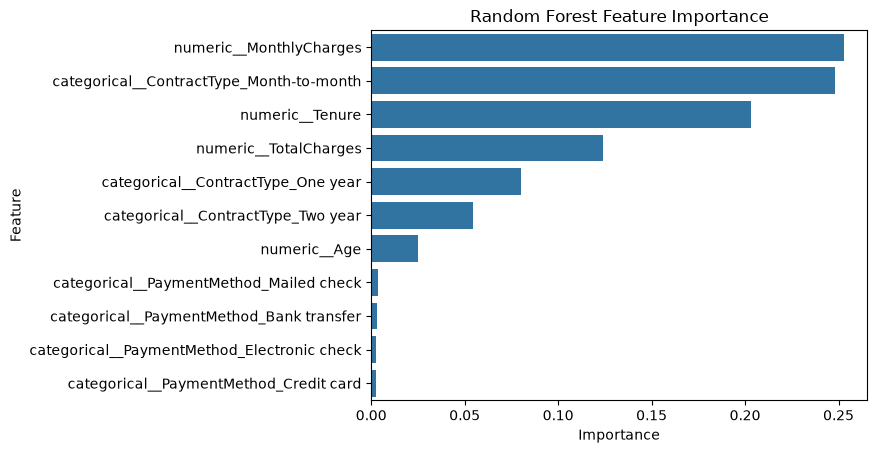

Feature importance graph displayed.


In [76]:
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

print("Feature importance graph displayed.")

# Compare Both Models

In [77]:
print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

print(
    "Logistic Regression ROC-AUC:",
    logistic_auc
)

print()

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

print(
    "Random Forest ROC-AUC:",
    rf_auc
)

Logistic Regression Accuracy: 0.9
Logistic Regression ROC-AUC: 0.9639340635025998

Random Forest Accuracy: 0.965
Random Forest ROC-AUC: 0.9953534683040159
